# Chameleon Screening
Short chameleon example notebook using the unified scalar BVP solver.

- Sweep over $\delta_c$
- Double-panel screening plot
- $|Q|$ and $m_\mathrm{eff}^2$ plot
- Effective potential plot

Note: modules are loaded from `../main`.

In [1]:
# Setup: import local modules from ../main
import sys, os, importlib, warnings, io, contextlib

warnings.filterwarnings("ignore")

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
main_dir = os.path.join(repo_root, "main")
if main_dir not in sys.path:
    sys.path.insert(0, main_dir)

# Reload dependency chain: physics_utils → plotting → escut
import physics_utils as _physics_mod
importlib.reload(_physics_mod)
import plotting as _plotting_mod
importlib.reload(_plotting_mod)
import escut
importlib.reload(escut)

# Single-surface import: pull everything from escut
from escut import (
    solve_scalar_bvp as _solve_scalar_bvp,
    plot_double_panel,
    plot_profiles_and_effective_mass_combined,
    compute_n_slope,
    make_initial_guess_from_analytic,
)

# Wrap solver to suppress warnings
def solve_scalar_bvp(*args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return _solve_scalar_bvp(*args, **kwargs)

import numpy as np
import matplotlib.pyplot as plt

## Sweep over δc
We vary the central overdensity $\delta_c$, solve for each, and produce the
double-panel figure (flux on top, slope $n(x)$ on bottom) coloured by $\log_{10}(\delta_c)$.

In [3]:
A = 1.0
B = -1e1
C = -1e1
F = 0
S = 1.0
delta_inf = 1e-10
eps_edge = 0.015

xmin, xmax = 1e-2, 1e2
npoints = 800
tol = 1e-6
max_nodes = 1_000_000

delta_cs = np.logspace(1, 5, 5)  # 1e1 .. 1e5
sols = []
linrefs = []
for dc in delta_cs:
    sol = solve_scalar_bvp(A=A, B=B, C=C, D=0.0, E=0.0, F=F,
                           S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                           xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=False, max_nodes=max_nodes)
    sols.append(sol)
    sol_lin = solve_scalar_bvp(A=A, B=B, C=0.0, D=0.0, E=0.0, F=0.0,
                               S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                               xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=False, max_nodes=max_nodes)
    linrefs.append(sol_lin)

x = np.logspace(np.log10(xmin), np.log10(xmax), 1200)

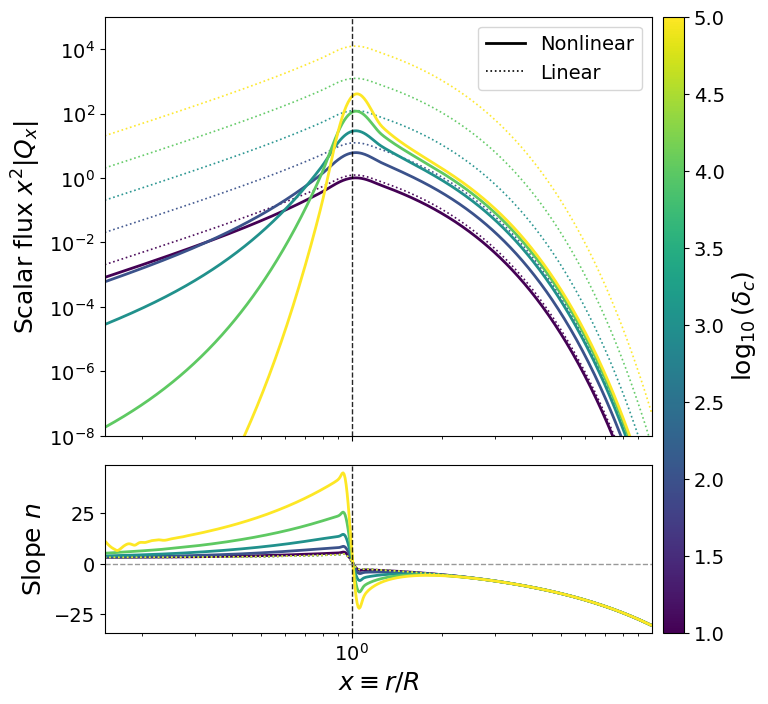

In [4]:
from matplotlib.lines import Line2D

# Optional controls for edge artifacts near x~1e-1
remove_highest_delta_c = False   # set True to drop delta_c=1e5 branch
x_plot_min = 0.15                # ignore left-edge boundary layer in display
x_plot_max = 1e1

x_plot = x[(x >= x_plot_min) & (x <= x_plot_max)]

if remove_highest_delta_c:
    sols_plot = sols[:-1]
    linrefs_plot = linrefs[:-1]
else:
    sols_plot = sols
    linrefs_plot = linrefs

# Two-panel figure: derivative (top) and slope n(x) (bottom) for chameleon sweep
fig, (ax_top, ax_bot), xV_map = plot_double_panel(
    x_plot, sols_plot,
    linrefs=linrefs_plot,
    cmap_name="viridis",
    lw_num=2.0, lw_lin=1.2, lin_ls=":",
    smooth_win_deriv=61, smooth_poly_deriv=3,
    smooth_win_vain=21, smooth_poly_vain=3,
    S=S, delta_inf=delta_inf, eps_edge=eps_edge,
    figsize=(8, 8),
    vradius="full", vline_alpha=0.5, vline_lw=1.0, vline_ls="striped",
    show_horizontal_guides=False,
    label_fontsize=18,
    tick_fontsize=14,
    cbar_fontsize=18,
)

# Hide grid on both panels
for ax in [ax_top, ax_bot]:
    ax.grid(True, which='major', alpha=0.0)
    ax.grid(True, which='minor', alpha=0.0)

# Add only the n=0 reference line in slope panel
ax_bot.axhline(0.0, color='gray', ls='--', lw=1.0, alpha=0.8)

legend_elements = [
    Line2D([0], [0], color='black', lw=2.0, label='Nonlinear'),
    Line2D([0], [0], color='black', lw=1.2, linestyle=':', label='Linear')
]
ax_top.legend(handles=legend_elements, loc='upper right', fontsize=14)

# Requested y-range tweak for upper panel
ax_top.set_ylim(bottom=1e-8)

fig.savefig('chameleon_double_panel.pdf', dpi=300, bbox_inches='tight')

plt.show()
xV_map

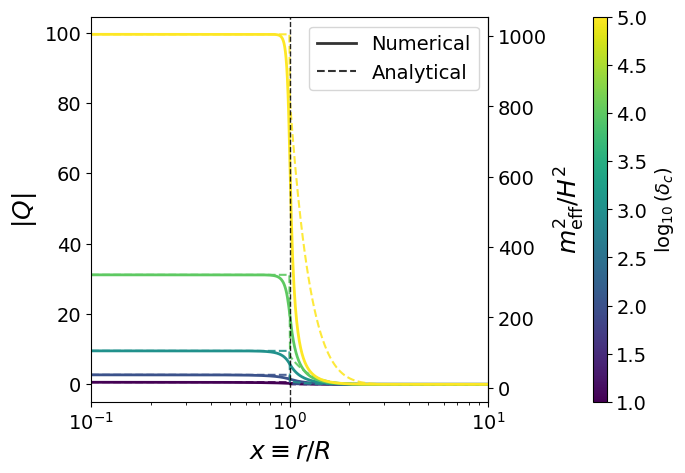

In [5]:
from escut import analytic_Q_thin_shell

x_m   = np.logspace(np.log10(0.1), np.log10(10.0), 600)  # 1e-1 .. 1e1, log-spaced
gamma = 1.0
sign  = -1.0

# Pre-compute thin-shell analytical profiles (one array per δ_c)
anrefs = [
    analytic_Q_thin_shell(
        x_m, A=A, B=B, C=C, S=S,
        delta_c=float(dc), delta_inf=delta_inf, eps_edge=eps_edge,
    )
    for dc in delta_cs
]

plot_profiles_and_effective_mass_combined(
    x_m, sols,
    anrefs=anrefs,
    B=B, C=C,
    gamma=gamma,
    sign=sign,
    cmap_name="viridis",
    lw_num=2.0,
    twin_axes=True,
    figsize=(11, 5),
    save="chameleon_Q_meff.pdf",
)
plt.show()

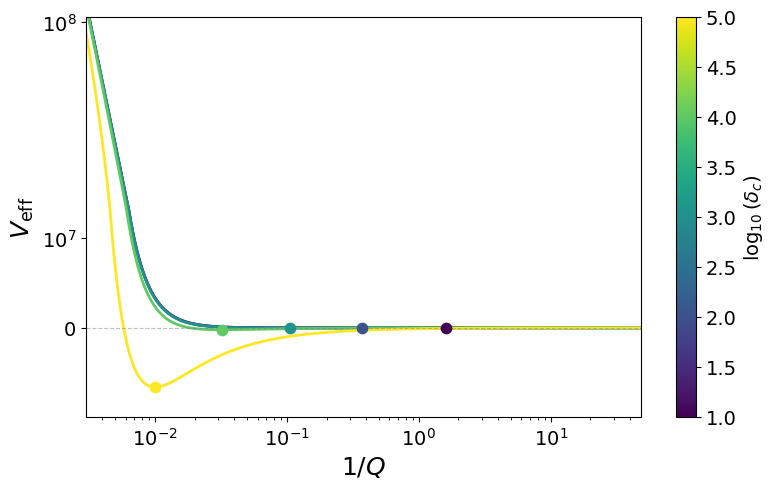

In [6]:
# §3 – Effective potential landscape
import importlib
import sys

# Reload in dependency order: physics_utils first, then plotting, then escut
for mod_name in ["physics_utils", "plotting", "escut"]:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from escut import plot_effective_potential

fig, ax = plot_effective_potential(
    delta_cs, A, B, C, S,
    save="chameleon_effective_potential.pdf",
)
plt.show()
